In [19]:
!pip install -q \
langchain \
langgraph \
langchain-community \
langchain-core \
pypdf \
python-dotenv \
groq \
langchain-groq \
pymupdf

print("dependencies installation completed")

dependencies installation completed


In [20]:
from google.colab import userdata
import os

# Set your Groq API Key
os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

In [21]:
!apt-get install -y tesseract-ocr poppler-utils
!pip install -q pytesseract pdf2image pypdf pillow

print("Installed dependencies for image extraction from pdf")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.
Installed dependencies for image extraction from pdf


In [22]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0
)

print("LLM Ready")

LLM Ready


In [23]:
import PIL.Image as PILImage
import io

def pix_to_pil(pix):
    """Convert PyMuPDF pixmap to PIL Image safely"""
    if pix.n >= 4:
        mode = "RGBA"
    else:
        mode = "RGB"

    return PILImage.frombytes(mode, [pix.width, pix.height], pix.samples)


In [24]:
import fitz  # PyMuPDF
import pytesseract
from PIL import Image


def is_text_valid(text):
    if not text:
        return False

    text = text.strip()

    # very small chunks are usually useless
    if len(text) < 30:
        return False

    # sometimes extraction gives weird chars
    bad_chars = sum(1 for c in text if not c.isprintable())
    if bad_chars > len(text) * 0.1:
        return False

    # if spaces are too less → likely broken text
    if text.count(" ") < len(text) * 0.1:
        return False

    return True


def is_valid_image_block(bbox):
    x0, y0, x1, y1 = bbox
    w = x1 - x0
    h = y1 - y0

    if h == 0:
        return False

    area = w * h
    ratio = w / h

    # skip tiny stuff (icons, lines etc.)
    if w < 50 or h < 50:
        return False

    if area < 2000:
        return False

    # skip long lines / weird shapes
    if ratio > 10 or ratio < 0.1:
        return False

    return True


def ocr_bbox(page, bbox):
    print(f"      -> OCR bbox {bbox}")

    rect = fitz.Rect(*bbox)
    mat = fitz.Matrix(2, 2)  # slight upscale helps OCR

    pix = page.get_pixmap(matrix=mat, clip=rect)
    img = PILImage.frombytes("RGB", [pix.width, pix.height], pix.samples)

    text = pytesseract.image_to_string(img, config="--oem 3 --psm 6")
    return text.strip()


def perform_ocr(page):
    print("   -> fallback full page OCR")

    mat = fitz.Matrix(2, 2)
    pix = page.get_pixmap(matrix=mat)

    img = pix_to_pil(pix)
    return pytesseract.image_to_string(img, config="--oem 3 --psm 6").strip()


def document_loader_tool(pdf_path):
    print(f"\nStarting processing: {pdf_path}")

    doc = fitz.open(pdf_path)
    final_output = []

    for page_idx, page in enumerate(doc):
        print("\n-----------------------------------")
        print(f"Page {page_idx + 1}")

        blocks = page.get_text("dict")["blocks"]
        print(f"blocks found: {len(blocks)}")

        page_content = []

        for idx, b in enumerate(blocks):
            print(f"\n  block {idx + 1} | type = {b['type']}")

            # TEXT BLOCK
            if b["type"] == 0:
                lines_text = []

                for line in b.get("lines", []):
                    spans = [span["text"] for span in line.get("spans", [])]
                    line_text = " ".join(spans)
                    lines_text.append(line_text)

                text = "\n".join(lines_text).strip()
                print(f"    text len: {len(text)}")

                if is_text_valid(text):
                    print("    using extracted text")
                    page_content.append(text)
                else:
                    print("    text looks bad → OCR block")
                    page_content.append(ocr_bbox(page, b["bbox"]))

            # IMAGE BLOCK
            elif b["type"] == 1:
                print(f"    image bbox: {b['bbox']}")

                if is_valid_image_block(b["bbox"]):
                    print("    running OCR on image")
                    img_text = ocr_bbox(page, b["bbox"])
                    page_content.append(img_text)
                else:
                    print("    skipped (too small / noise)")

        # fallback if nothing useful
        if not page_content:
            print("  nothing extracted → full OCR")
            page_content.append(perform_ocr(page))
        else:
            print("  page processed")

        final_output.append("\n".join(page_content))

    print("\nDone processing\n")
    return final_output

In [25]:
import json
import re


def extract_json(text):
    """Extract JSON from LLM response safely"""
    try:
        return json.loads(text)
    except:
        pass

    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except:
            pass

    return None


def classify_document(text):
    if not text or len(text.strip()) < 20:
        return {
            "label": "Uncertain",
            "confidence": 0,
            "reason": "Empty or insufficient text"
        }

    # ✅ FIX: Proper indentation (4 spaces)
    prompt = f"""
You are a strict legal document classifier.

Classify the document into ONLY one of:
- Cease
- Irrelevant
- Uncertain

STRICT RULES:

Cease:
- ONLY if there is a clear, explicit, and direct instruction to STOP ALL communication
- Examples:
  - "Cease and desist all communication"
  - "Do not contact me"
  - "Stop all calls, emails, or messages"

Uncertain:
- If communication is LIMITED, REDUCED, or INDIRECTLY restricted
- Examples:
  - "prefer limited communication"
  - "please minimize calls"
  - "contact via email only"
  - "avoid frequent calls"

Irrelevant:
- No restriction on communication

IMPORTANT:
- Do NOT classify as Cease unless it is explicit and absolute
- If unsure → choose Uncertain

Return ONLY JSON:
{{
    "label": "Cease | Irrelevant | Uncertain",
    "confidence": number (0-100),
    "reason": "short explanation"
}}

Document:
\"\"\"{text}\"\"\"
"""

    try:
        response = llm.invoke(prompt)
        raw_output = response.content.strip()

        print("🔍 Raw LLM output:", raw_output[:200])

        parsed = extract_json(raw_output)

        if not parsed:
            print("⚠️ Failed to parse JSON → fallback")
            return {
                "label": "Uncertain",
                "confidence": 0,
                "reason": "Invalid LLM response format"
            }

        label = parsed.get("label", "Uncertain")
        confidence = parsed.get("confidence", 0)
        reason = parsed.get("reason", "")

        if label not in ["Cease", "Irrelevant", "Uncertain"]:
            label = "Uncertain"

        try:
            confidence = int(confidence)
        except:
            confidence = 0

        confidence = max(0, min(confidence, 100))

        return {
            "label": label,
            "confidence": confidence,
            "reason": reason
        }

    except Exception as e:
        print("❌ LLM error:", str(e))

        return {
            "label": "Uncertain",
            "confidence": 0,
            "reason": "LLM invocation failed"
        }

In [26]:
import json

def extraction_tool(text):
    """
    Extract key details from a Cease & Desist document.
    NOTE:
    - Only extracts document content
    - Does NOT include system metadata (doc name, received date)
    """

    prompt = f"""
    You are an expert information extraction system.

    Extract key details from this document.

    Rules:
    - Return STRICT JSON ONLY (no explanation)
    - If a value is missing → return null
    - Do NOT hallucinate or guess
    - Keep output clean and valid JSON

    Required JSON format:
    {{
        "name": null or string,
        "date": null or string,
        "reason": null or string,
        "contact": null or string
    }}

    Document:
    {text}
    """

    response = llm.invoke(prompt).content

    parsed = extract_json(response)

    # Fallback if parsing fails
    if parsed is None:
        return {
            "name": None,
            "date": None,
            "reason": None,
            "contact": None,
            "error": "parsing_failed",
            "raw_output": response
        }

    return parsed

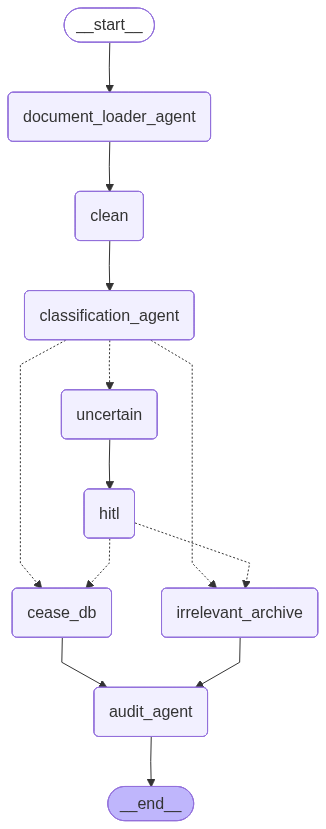

In [27]:
# ===============================
# INSTALL (run once in Colab)
# ===============================
# !pip install langgraph langchain langchain-core pymupdf pytesseract pillow

# ===============================
# IMPORTS
# ===============================
from langgraph.graph import StateGraph, END
from datetime import datetime
import uuid
import re
import json

# ===============================
# STATE
# ===============================
from typing import TypedDict

class State(TypedDict, total=False):
    doc_path: str
    doc_name: str
    text: str
    classification: dict
    extraction: dict
    decision: str
    execution_id: str


# ===============================
# NODES
# ===============================

def document_loader_agent(state):
    try:
        print("📥 FULL STATE:", state)
        doc_path = state.get("doc_path")

        if not doc_path:
            raise ValueError("Missing doc_path")

        pages = document_loader_tool(doc_path)
        text  = "\n".join(pages)

        audit_agent("DOCUMENT_LOADED", f"{len(pages)} pages", doc_name=state.get("doc_name"))

    except Exception as e:
        audit_agent("LOAD_ERROR", str(e), level="ERROR")
        text  = ""

    return {
    **state,
    "text": text
}


def clean_text_node(state):
    try:
        text = state.get("text", "")

        text = re.sub(r"_+", "", text)
        text = re.sub(r"\s+", " ", text)

        state["text"] = text.strip()

        audit_agent("TEXT_CLEANED", f"Length: {len(state['text'])}", doc_name=state.get("doc_name"))

    except Exception as e:
        audit_agent("CLEAN_ERROR", str(e), level="ERROR")

    return {
    **state,
    "text": text
}


def classification_agent(state):
    try:
        text = state.get("text", "")

        if not text.strip():
            raise ValueError("Empty text")

        result = classify_document(text)

        print("🔍 RAW CLASSIFIER OUTPUT:", result)

        label = result.get("label", "Uncertain")
        confidence = result.get("confidence", 0)

        if confidence < 75:
            label = "Uncertain"

        if label not in ["Cease", "Irrelevant", "Uncertain"]:
            label = "Uncertain"

        print("✅ FINAL LABEL:", label)

        state["classification"] = {
            "label": label,
            "confidence": confidence
        }

        audit_agent("CLASSIFICATION", state["classification"], doc_name=state.get("doc_name"))

    except Exception as e:
        audit_agent("CLASSIFICATION_ERROR", str(e), level="ERROR")
        state["classification"] = {"label": "Uncertain", "confidence": 0}

    return {
    **state,
    "text": text,
    "classification": state["classification"]
}


# ===============================
# ROUTING
# ===============================
def route_node(state):
    label = state.get("classification", {}).get("label", "Uncertain")

    print("🚦 ROUTING LABEL:", label)

    if label == "Cease":
        return "cease_db"
    elif label == "Irrelevant":
        return "irrelevant_archive"
    else:
        return "uncertain"


def hitl_route(state):
    decision = state.get("decision", "Irrelevant")

    if decision == "Cease":
        return "cease_db"
    else:
        return "irrelevant_archive"


# ===============================
# UNCERTAIN NODE
# ===============================
def uncertain_node(state):
    print("⚠️ Entered UNCERTAIN → going to HITL")
    return {
    **state
}


# ===============================
# HITL NODE
# ===============================
def hitl_node(state):
    try:
        text = state.get("text", "")
        doc_name = state.get("doc_name")

        decision = hitl_agent(text, doc_name)
        decision = decision.strip().capitalize()

        if decision not in ["Cease", "Irrelevant"]:
            decision = "Irrelevant"

        state["decision"] = decision

        audit_agent("HUMAN_REVIEW", f"Decision: {decision}", doc_name=doc_name)

    except Exception as e:
        audit_agent("HITL_ERROR", str(e), level="ERROR")
        state["decision"] = "Irrelevant"

    return {
    **state,
    "text": text
}


# ===============================
# CEASE → DATABASE NODE
# ===============================
def cease_db_node(state):
    try:
        text = state.get("text", "")

        extracted = extraction_tool(text)
        state["extraction"] = extracted

        database_agent(state.get("doc_name"), extracted)

        audit_agent("DB_STORED", "Stored in DB (Cease)", doc_name=state.get("doc_name"))

    except Exception as e:
        audit_agent("DB_ERROR", str(e), level="ERROR")

    return {
    **state,
    "text": text
}


# ===============================
# IRRELEVANT → ARCHIVE NODE
# ===============================
def irrelevant_archive_node(state):
    try:
        archive_agent(state.get("doc_name"))

        audit_agent("ARCHIVED", "Document archived (Irrelevant)", doc_name=state.get("doc_name"))

    except Exception as e:
        audit_agent("ARCHIVE_ERROR", str(e), level="ERROR")

    return {
    **state
    }


# ===============================
# FINAL AUDIT NODE (NEW)
# ===============================
def audit_agent_node(state):
    try:
        doc_name = state.get("doc_name")
        classification = state.get("classification", {}).get("label", "Unknown")
        decision = state.get("decision", "N/A")

        audit_agent(
            "FINAL_STATUS",
            f"Classification={classification}, Decision={decision}",
            doc_name=doc_name
        )

        print("✅ Final audit completed")

    except Exception as e:
        audit_agent("audit_agent_ERROR", str(e), level="ERROR")

    print("📊 Final State:", state)
    return state


# ===============================
# HITL AGENT
# ===============================
def hitl_agent(text, doc_name=None):

    print("\n" + "="*50)
    print("⚠️ HUMAN REVIEW REQUIRED")

    if doc_name:
        print(f"Document: {doc_name}")

    print("\n--- Document Preview ---")
    print(text[:500])
    print("-"*50)

    while True:
        decision = input("Enter decision (Cease / Irrelevant): ").strip().lower()

        if decision in ["cease", "irrelevant"]:
            decision = decision.capitalize()
            print(f"✅ Selected: {decision}")
            return decision

        print("❌ Invalid input.")

def database_agent(doc_name, extracted):
    import sqlite3
    from datetime import datetime, UTC

    conn = sqlite3.connect("documents.db")
    cursor = conn.cursor()

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS documents (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            doc_name TEXT,
            extracted_data TEXT,
            created_at TEXT
        )
    """)

    cursor.execute("""
        INSERT INTO documents (doc_name, extracted_data, created_at)
        VALUES (?, ?, ?)
    """, (
        doc_name,
        json.dumps(extracted),
        datetime.now(UTC).isoformat()
    ))

    conn.commit()
    conn.close()

    print(f"✅ Stored in DB: {doc_name}")

# ===============================
# SUPPORT
# ===============================
from datetime import datetime, UTC
import json

def audit_agent(action, details, level="INFO", doc_name=None):
    record = {
        "timestamp": datetime.now(UTC).isoformat(),
        "level": level,
        "action": action,
        "details": details
    }

    if doc_name:
        record["document_name"] = doc_name

    try:
        with open("audit.log", "a") as f:
            f.write(json.dumps(record) + "\n")

        print(f"[{level}] {action} → {details}")

    except Exception as e:
        print(f"[ERROR] audit logging failed: {str(e)}")


def archive_agent(doc_name):
    record = {
        "document_name": doc_name,
        "timestamp": datetime.utcnow().isoformat()
    }

    with open("archive.txt", "a") as f:
        f.write(json.dumps(record) + "\n")

    print(f"Archived: {doc_name}")


# ===============================
# BUILD GRAPH
# ===============================
builder = StateGraph(State)

builder.add_node("document_loader_agent", document_loader_agent)
builder.add_node("clean", clean_text_node)
builder.add_node("classification_agent", classification_agent)

builder.add_node("uncertain", uncertain_node)
builder.add_node("hitl", hitl_node)

builder.add_node("cease_db", cease_db_node)
builder.add_node("irrelevant_archive", irrelevant_archive_node)

builder.add_node("audit_agent", audit_agent_node)

builder.set_entry_point("document_loader_agent")

builder.add_edge("document_loader_agent", "clean")
builder.add_edge("clean", "classification_agent")

builder.add_conditional_edges(
    "classification_agent",
    route_node,
    {
        "cease_db": "cease_db",
        "irrelevant_archive": "irrelevant_archive",
        "uncertain": "uncertain"
    }
)

builder.add_edge("uncertain", "hitl")

builder.add_conditional_edges(
    "hitl",
    hitl_route,
    {
        "cease_db": "cease_db",
        "irrelevant_archive": "irrelevant_archive"
    }
)

# 🔥 FINAL FLOW CHANGE
builder.add_edge("cease_db", "audit_agent")
builder.add_edge("irrelevant_archive", "audit_agent")

builder.add_edge("audit_agent", END)

graph = builder.compile()


# ===============================
# VISUALIZE GRAPH
# ===============================

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png(max_retries=5)))
except Exception:
    print("PNG failed → using text instead\n")
    print(graph.get_graph().draw_mermaid())

In [28]:
import sqlite3

def clear_sqlite_table(db_path="documents.db", table_name="documents"):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute(f"DELETE FROM {table_name}")
    conn.commit()

    conn.close()
    print(f"✅ Cleared all records from {table_name}")

In [29]:
# import os
# print(os.path.exists("./sample_docs/LOA2.pdf"))

# doc_path = "./sample_docs/LOA2.pdf"
# doc_name = "test_doc_1"

# def run_pipeline(doc_path, doc_name):
#     return graph.invoke({
#     "doc_path": doc_path,
#     "doc_name": doc_name,
#     "execution_id": str(uuid.uuid4())
# })

#     # return graph.invoke(initial_state)

# # 🔥 CALL THE FUNCTION
# result = run_pipeline(doc_path, doc_name)

# print("\n✅ FINAL RESULT:\n", result)

In [30]:
import os
import shutil
import traceback

# ===============================
# CONFIG
# ===============================
INPUT_DIR = "sample_docs"
COMPLETED_DIR = "completed"
ERROR_DIR = "error"

# create folders if not exist
os.makedirs(COMPLETED_DIR, exist_ok=True)
os.makedirs(ERROR_DIR, exist_ok=True)


# ===============================
# PROCESS FUNCTION
# ===============================
def process_all_documents():

    files = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(".pdf")]

    print(f"📂 Found {len(files)} documents\n")

    for file_name in files:
        file_path = os.path.join(INPUT_DIR, file_name)

        print("\n" + "="*60)
        print(f"🚀 Processing: {file_name}")

        try:
            # 🔥 Run your LangGraph pipeline
            result = run_pipeline(
                doc_path=file_path,
                doc_name=file_name
            )

            print("✅ SUCCESS:", file_name)

            # 🔥 Move to completed
            shutil.move(file_path, os.path.join(COMPLETED_DIR, file_name))
            print(f"📁 Moved to {COMPLETED_DIR}")

        except Exception as e:
            print(f"❌ ERROR processing {file_name}")
            print(str(e))

            traceback.print_exc()

            # 🔥 Move to error folder
            shutil.move(file_path, os.path.join(ERROR_DIR, file_name))
            print(f"📁 Moved to {ERROR_DIR}")


# ===============================
# RUN
# ===============================
process_all_documents()

📂 Found 19 documents


🚀 Processing: bw_doc_1.pdf
📥 FULL STATE: {'doc_path': 'sample_docs/bw_doc_1.pdf', 'doc_name': 'bw_doc_1.pdf', 'execution_id': 'cf4970f1-0e5d-4d69-bd66-1b815b8673a2'}

Starting processing: sample_docs/bw_doc_1.pdf

-----------------------------------
Page 1
blocks found: 1

  block 1 | type = 1
    image bbox: (0.0, 0.0, 595.2000122070312, 841.9199829101562)
    running OCR on image
      -> OCR bbox (0.0, 0.0, 595.2000122070312, 841.9199829101562)
  page processed

Done processing

[INFO] DOCUMENT_LOADED → 1 pages
[INFO] TEXT_CLEANED → Length: 1307
🔍 Raw LLM output: {
    "label": "Uncertain",
    "confidence": 80,
    "reason": "The document mentions 'limited Power of Attorney' and 'authorized interactions', indicating restricted communication, but does not expl
🔍 RAW CLASSIFIER OUTPUT: {'label': 'Uncertain', 'confidence': 80, 'reason': "The document mentions 'limited Power of Attorney' and 'authorized interactions', indicating restricted communication, but does

/tmp/ipykernel_4362/4092513518.py:329: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()



  block 2 | type = 0
    text len: 62
    text looks bad → OCR block
      -> OCR bbox (31.079242706298828, 150.88763427734375, 268.0470886230469, 165.67213439941406)

  block 3 | type = 0
    text len: 151
    using extracted text

  block 4 | type = 0
    text len: 168
    using extracted text

  block 5 | type = 0
    text len: 354
    using extracted text

  block 6 | type = 0
    text len: 115
    using extracted text

  block 7 | type = 0
    text len: 364
    using extracted text

  block 8 | type = 0
    text len: 664
    using extracted text

  block 9 | type = 0
    text len: 202
    using extracted text

  block 10 | type = 0
    text len: 96
    using extracted text

  block 11 | type = 0
    text len: 23
    text looks bad → OCR block
      -> OCR bbox (58.01676559448242, 557.43994140625, 162.4763946533203, 575.2938842773438)

  block 12 | type = 0
    text len: 361
    using extracted text

  block 13 | type = 0
    text len: 240
    using extracted text
  page processed

/tmp/ipykernel_4362/4092513518.py:329: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()



  block 2 | type = 0
    text len: 14
    text looks bad → OCR block
      -> OCR bbox (423.43328857421875, 59.08351516723633, 498.4762268066406, 75.08023834228516)

  block 3 | type = 0
    text len: 28
    text looks bad → OCR block
      -> OCR bbox (193.47296142578125, 144.8364715576172, 395.80255126953125, 170.65606689453125)

  block 4 | type = 0
    text len: 54
    using extracted text

  block 5 | type = 0
    text len: 15
    text looks bad → OCR block
      -> OCR bbox (24.871196746826172, 220.52200317382812, 112.49295806884766, 238.09738159179688)

  block 6 | type = 0
    text len: 36
    using extracted text

  block 7 | type = 0
    text len: 27
    text looks bad → OCR block
      -> OCR bbox (58.07927322387695, 284.9414978027344, 203.55789184570312, 303.6468811035156)

  block 8 | type = 0
    text len: 489
    using extracted text

  block 9 | type = 0
    text len: 323
    using extracted text

  block 10 | type = 0
    text len: 289
    using extracted text

  bloc

...


  block 2 | type = 0
    text len: 40
    using extracted text

  block 3 | type = 0
    text len: 34
    using extracted text

  block 4 | type = 0
    text len: 14
    text looks bad → OCR block
      -> OCR bbox (23.54615020751953, 255.16261291503906, 100.62989044189453, 273.4833679199219)

  block 5 | type = 0
    text len: 34
    using extracted text

  block 6 | type = 0
    text len: 24
    text looks bad → OCR block
      -> OCR bbox (55.22096633911133, 315.7437744140625, 193.75430297851562, 335.26300048828125)

  block 7 | type = 0
    text len: 457
    using extracted text

  block 8 | type = 0
    text len: 317
    using extracted text

  block 9 | type = 0
    text len: 442
    using extracted text

  block 10 | type = 0
    text len: 306
    using extracted text

  block 11 | type = 0
    text len: 52
    using extracted text

  block 12 | type = 0
    text len: 20
    text looks bad → OCR block
      -> OCR bbox (53.590843200683594, 695.0860595703125, 334.1964416503906, 

/tmp/ipykernel_4362/4092513518.py:329: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


  page processed

Done processing

[INFO] DOCUMENT_LOADED → 1 pages
[INFO] TEXT_CLEANED → Length: 1157
🔍 Raw LLM output: {
    "label": "Uncertain",
    "confidence": 80,
    "reason": "The document requests a temporary suspension of certain outbound correspondences while the underlying authorization and identity valida
🔍 RAW CLASSIFIER OUTPUT: {'label': 'Uncertain', 'confidence': 80, 'reason': 'The document requests a temporary suspension of certain outbound correspondences while the underlying authorization and identity validation are reviewed, but does not categorically bar all forms of contact.'}
✅ FINAL LABEL: Uncertain
[INFO] CLASSIFICATION → {'label': 'Uncertain', 'confidence': 80}
🚦 ROUTING LABEL: Uncertain
⚠️ Entered UNCERTAIN → going to HITL

⚠️ HUMAN REVIEW REQUIRED
Document: notice_2.pdf

--- Document Preview ---
Lowell & Partners — Regulatory Practice a 39 Ironforge Lane, Regulatory Square Customer Services Division Date: October 10,2025 Our firm represents an individual i

/tmp/ipykernel_4362/4092513518.py:329: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": datetime.utcnow().isoformat()


  page processed

Done processing

[INFO] DOCUMENT_LOADED → 1 pages
[INFO] TEXT_CLEANED → Length: 1048
🔍 Raw LLM output: {
    "label": "Uncertain",
    "confidence": 80,
    "reason": "The document requests 'limited release language' and 'cooperative engagement' but does not explicitly instruct to stop all communicatio
🔍 RAW CLASSIFIER OUTPUT: {'label': 'Uncertain', 'confidence': 80, 'reason': "The document requests 'limited release language' and 'cooperative engagement' but does not explicitly instruct to stop all communication. However, it does request 'limited' communication, which aligns with the Uncertain classification."}
✅ FINAL LABEL: Uncertain
[INFO] CLASSIFICATION → {'label': 'Uncertain', 'confidence': 80}
🚦 ROUTING LABEL: Uncertain
⚠️ Entered UNCERTAIN → going to HITL

⚠️ HUMAN REVIEW REQUIRED
Document: bw_doc_2.pdf

--- Document Preview ---
Faulkner, Pierce & Associates een 58 Eastgate Row, Advisory Tower [Scanned] Client Relations Dain October 1, 2008 Proposal of Settleme

In [31]:
import sqlite3

def print_all_records(db_path="documents.db", table_name="documents"):
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        cursor.execute(f"SELECT * FROM {table_name}")
        rows = cursor.fetchall()

        # Print column names
        column_names = [description[0] for description in cursor.description]
        print(" | ".join(column_names))
        print("-" * 80)

        # Print rows
        for row in rows:
            print(" | ".join(str(item) for item in row))

        if not rows:
            print("No records found.")

    except Exception as e:
        print("Error:", e)

    finally:
        conn.close()


# 🔥 CALL FUNCTION
print_all_records()

id | doc_name | extracted_data | created_at
--------------------------------------------------------------------------------
3 | LOA8.pdf | {"name": "Garder, Bobbi R", "date": "08/05/1972", "reason": "Authorization to Communicate with Creditors and Collection Agencies", "contact": "Cordoba Legal Group, LLC, 102 NE 2nd Street #252, Boca Raton, FL 33432"} | 2026-03-23T02:02:14.408227+00:00
4 | bw_doc_3.pdf | {"name": "Harrington Legal Counsel", "date": "October 1, 2023", "reason": "Routine compliance audit", "contact": null} | 2026-03-23T02:02:25.484951+00:00
5 | notice_5.pdf | {"name": "Merrit & Cole, Attorneys", "date": "October 1, 2028", "reason": "review of records that speak to authorization to contact and limit certain outreach activities", "contact": "2 Redwood Terrace, Legal Quarter"} | 2026-03-23T02:02:34.550489+00:00
6 | LOA6.pdf | {"name": "BELLINA DAVANZO AMOEDO, RADCLIFF", "date": "29/06/2025", "reason": null, "contact": "800-95-3896"} | 2026-03-23T02:02:54.714524+00:00
7 | 

In [32]:
# import sqlite3

# def clear_all_records(db_path="documents.db", table_name="documents"):
#     try:
#         conn = sqlite3.connect(db_path)
#         cursor = conn.cursor()

#         cursor.execute(f"DELETE FROM {table_name}")
#         conn.commit()

#         print(f"✅ All records deleted from '{table_name}'")

#     except Exception as e:
#         print("❌ Error:", e)

#     finally:
#         conn.close()


# # 🔥 CALL
# clear_all_records()